# Building a Supervised Learning Model with EDA using a Kaggle Dataset

**Name:** Sneha G

**Dataset:** Medical Cost Personal Datasets (Kaggle) — `insurance.csv`
Source: https://www.kaggle.com/datasets/mirichoi0218/insurance


## Task 1: Dataset Selection

The **Medical Cost Personal Datasets** from Kaggle was selected for this project.

- It contains 1,338 records of individuals with demographic and lifestyle attributes.
- The target variable is **`charges`** (individual medical insurance cost billed by health insurance), which is a **continuous numeric variable** — making it well-suited for a **Linear Regression** model.


## Task 2: Problem Definition

**What we are trying to predict:** The individual medical insurance `charges` billed to a person, based on their personal and lifestyle attributes.

**Type of problem:** Regression (the target variable `charges` is continuous).

**Input features (X):**
- `age` — age of the primary beneficiary
- `sex` — gender (male/female)
- `bmi` — Body Mass Index
- `children` — number of dependents covered by insurance
- `smoker` — smoking status (yes/no)
- `region` — residential area in the US

**Target variable (y):**
- `charges` — individual medical costs billed by health insurance


## Task 3: Data Loading & Understanding

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

df = pd.read_csv("insurance.csv")
df.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
print("Dataset shape:", df.shape)
print("\nColumn names:", list(df.columns))


Dataset shape: (1338, 7)

Column names: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']


In [ ]:
print("Data types:\n")
print(df.dtypes)


Data types:

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object


In [ ]:
print("Missing values per column:\n")
print(df.isnull().sum())


Missing values per column:

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


## Task 4: Data Cleaning

Checking for missing values and duplicate rows, and confirming that data types are appropriate for analysis.


In [ ]:
print("Number of duplicate rows:", df.duplicated().sum())

# Remove duplicates if any
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

# No missing values were found (confirmed in Task 3), so no imputation is needed.
# Data types are already appropriate: numeric columns (age, bmi, children, charges)
# and categorical columns (sex, smoker, region) are correctly typed as such.
df.describe(include='all')


Number of duplicate rows: 1
Shape after removing duplicates: (1337, 7)


,age,sex,bmi,children,smoker,region,charges
count,1337.000000,1337,1337.000000,1337.000000,1337,1337,1337.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,675,NaN,NaN,1063,364,NaN
mean,39.222139,NaN,30.663452,1.095737,NaN,NaN,13279.121487
std,14.044333,NaN,6.100468,1.205571,NaN,NaN,12110.359656
min,18.000000,NaN,15.960000,0.000000,NaN,NaN,1121.873900
25%,27.000000,NaN,26.290000,0.000000,NaN,NaN,4746.344000
50%,39.000000,NaN,30.400000,1.000000,NaN,NaN,9386.161300
75%,51.000000,NaN,34.700000,2.000000,NaN,NaN,16657.717450


## Task 5: Exploratory Data Analysis (EDA)

### Univariate Analysis: Distribution of Variables


/tmp/ipykernel_587/3566393592.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='smoker', data=df, ax=axes[1,1], palette='Set2')


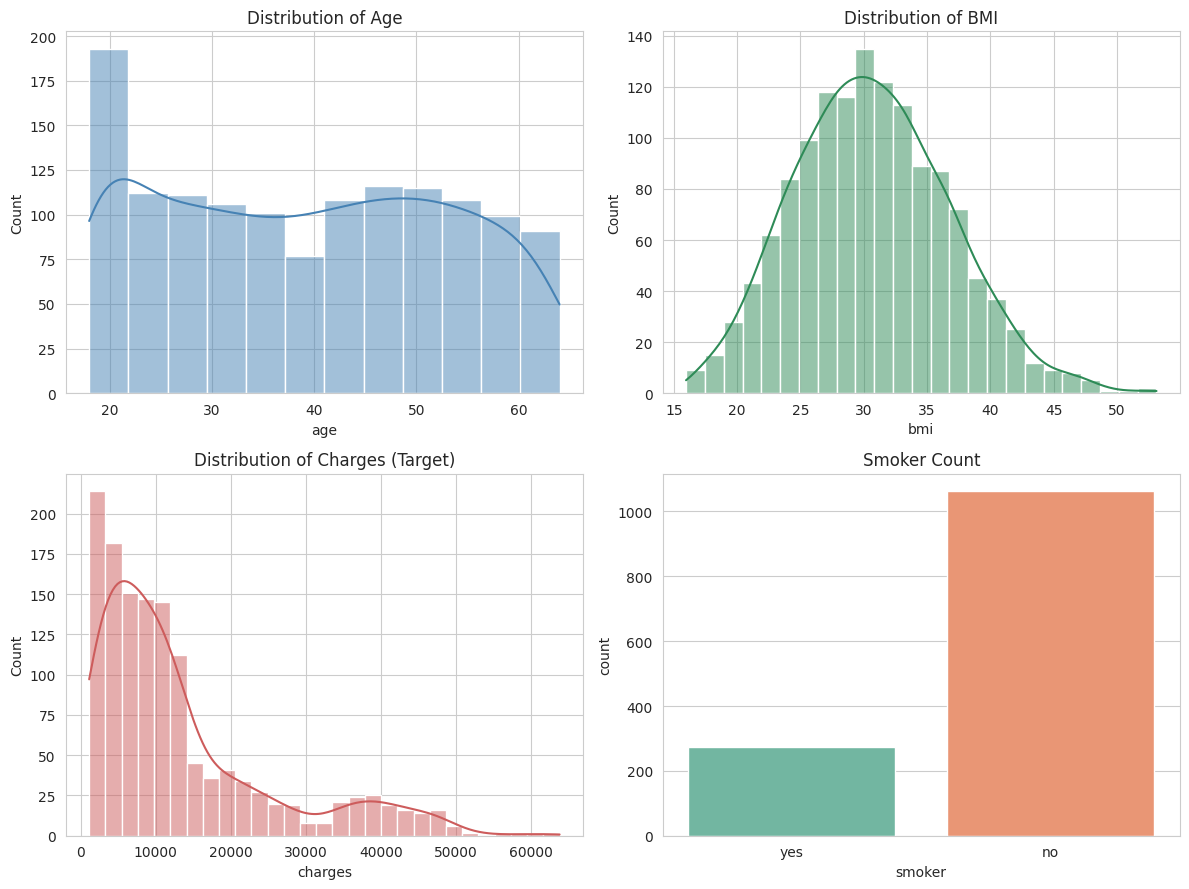

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

sns.histplot(df['age'], kde=True, ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Distribution of Age')

sns.histplot(df['bmi'], kde=True, ax=axes[0,1], color='seagreen')
axes[0,1].set_title('Distribution of BMI')

sns.histplot(df['charges'], kde=True, ax=axes[1,0], color='indianred')
axes[1,0].set_title('Distribution of Charges (Target)')

sns.countplot(x='smoker', data=df, ax=axes[1,1], palette='Set2')
axes[1,1].set_title('Smoker Count')

plt.tight_layout()
plt.show()


**Insight:** `age` is fairly uniformly spread across adults, `bmi` is roughly normally distributed around ~30, and `charges` is **strongly right-skewed** — most people have relatively low medical costs, but a smaller group (largely smokers, as we'll see) has very high charges. The dataset is dominated by non-smokers.


/tmp/ipykernel_587/3488441472.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='region', data=df, ax=axes[0], palette='pastel')
/tmp/ipykernel_587/3488441472.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sex', data=df, ax=axes[1], palette='pastel')


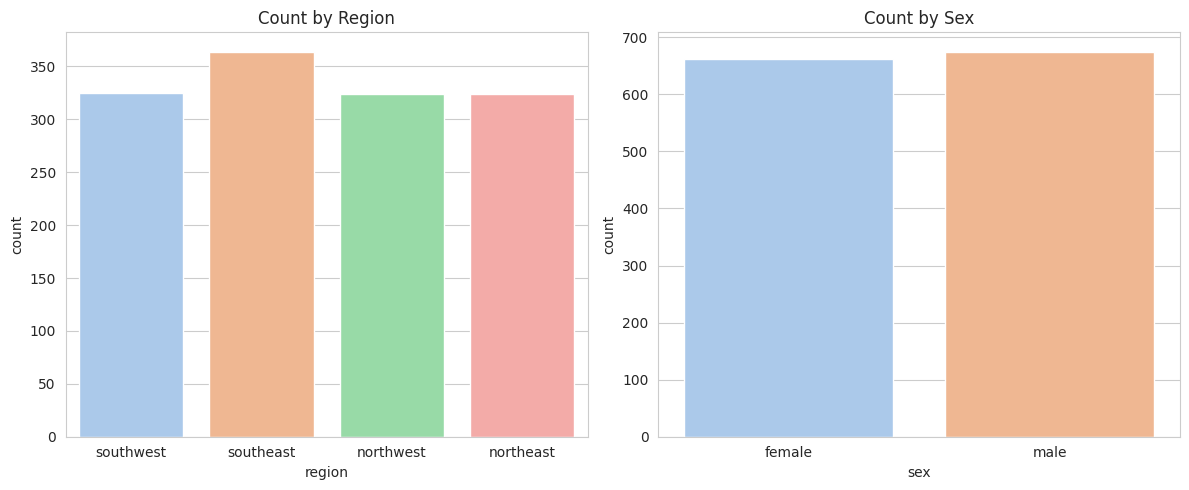

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(x='region', data=df, ax=axes[0], palette='pastel')
axes[0].set_title('Count by Region')

sns.countplot(x='sex', data=df, ax=axes[1], palette='pastel')
axes[1].set_title('Count by Sex')

plt.tight_layout()
plt.show()


**Insight:** The dataset is almost evenly split across the four US regions and between male and female, so there's no major class imbalance in these categorical features.


### Bivariate Analysis: Relationship Between Features and Target

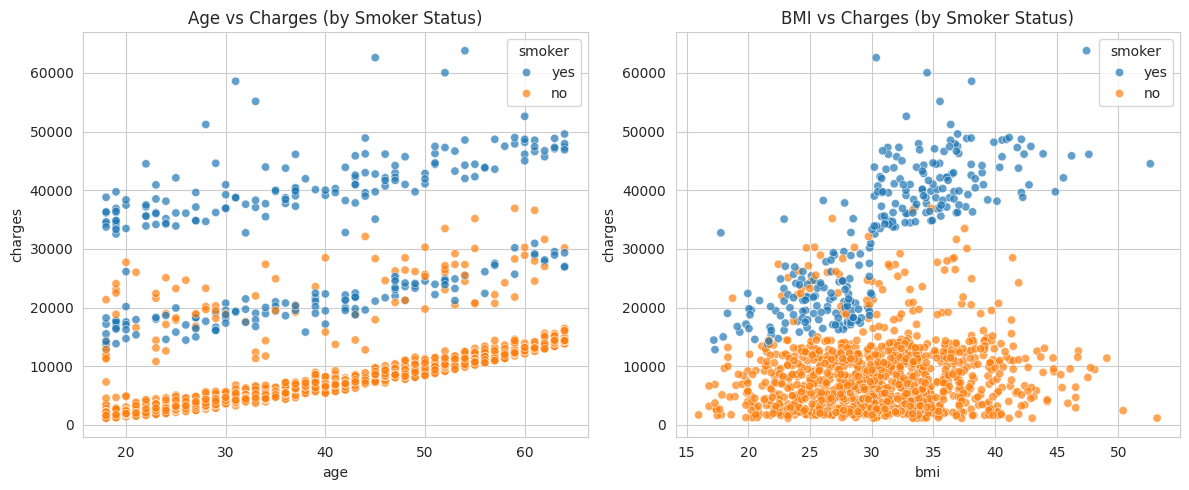

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(x='age', y='charges', hue='smoker', data=df, ax=axes[0], alpha=0.7)
axes[0].set_title('Age vs Charges (by Smoker Status)')

sns.scatterplot(x='bmi', y='charges', hue='smoker', data=df, ax=axes[1], alpha=0.7)
axes[1].set_title('BMI vs Charges (by Smoker Status)')

plt.tight_layout()
plt.show()


**Insight:** `age` shows a clear positive relationship with `charges` — costs rise steadily with age within each smoker group. `bmi` alone shows a weaker relationship for non-smokers, but for **smokers with high BMI, charges rise sharply**, suggesting an interaction effect between `smoker` and `bmi`.


/tmp/ipykernel_587/3286804040.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='smoker', y='charges', data=df, ax=axes[0], palette='Set2')
/tmp/ipykernel_587/3286804040.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='children', y='charges', data=df, ax=axes[1], palette='Blues')


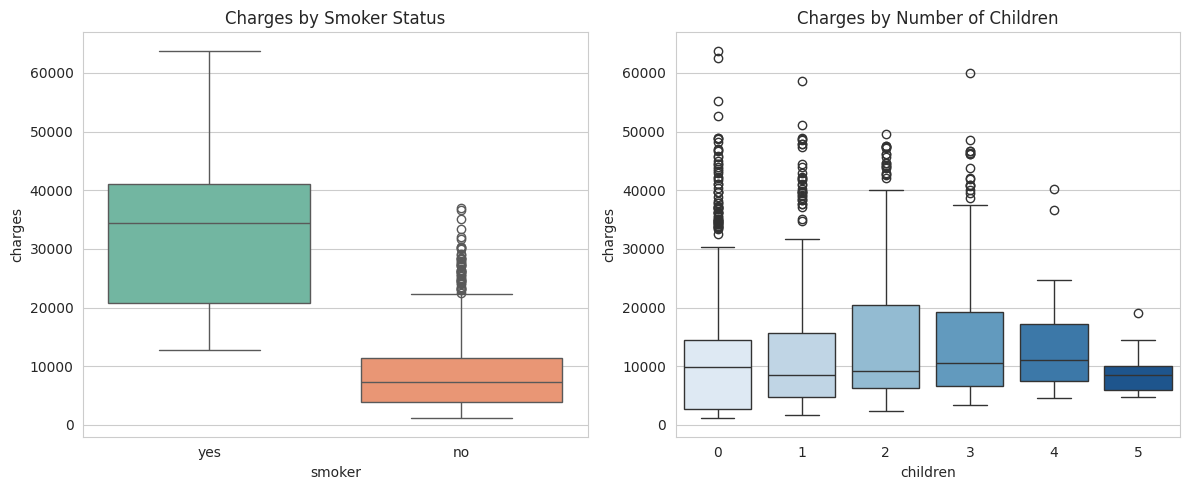

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x='smoker', y='charges', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Charges by Smoker Status')

sns.boxplot(x='children', y='charges', data=df, ax=axes[1], palette='Blues')
axes[1].set_title('Charges by Number of Children')

plt.tight_layout()
plt.show()


**Insight:** `smoker` status has by far the strongest visible effect — smokers pay dramatically higher median charges than non-smokers, with a much wider spread. Number of `children` has little to no clear effect on charges.


### Correlation Analysis

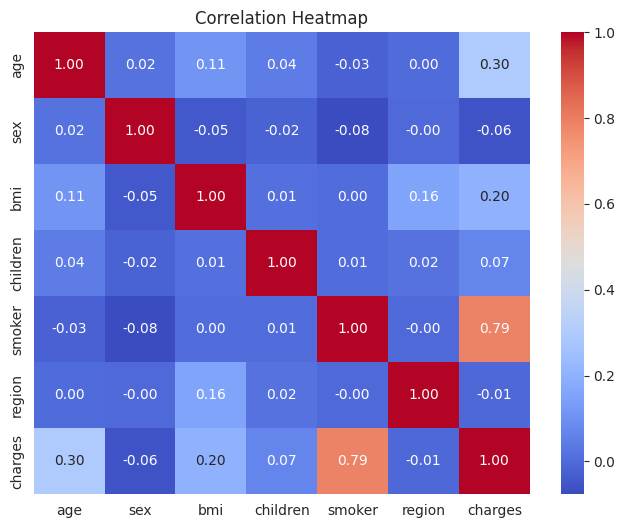

In [ ]:
df_encoded = df.copy()
df_encoded['sex'] = df_encoded['sex'].map({'male': 0, 'female': 1})
df_encoded['smoker'] = df_encoded['smoker'].map({'no': 0, 'yes': 1})
df_encoded['region'] = df_encoded['region'].astype('category').cat.codes

plt.figure(figsize=(8, 6))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()


**Insight:** `smoker` has the strongest correlation with `charges` (~0.79), followed by `age` (~0.30) and `bmi` (~0.20). `sex`, `children`, and `region` show very weak correlation with the target, meaning they contribute relatively little on their own for predicting charges.


## Task 6: Data Preprocessing

Categorical variables (`sex`, `smoker`, `region`) are encoded numerically using one-hot encoding, then the dataset is split into training (80%) and testing (20%) sets.


In [ ]:
from sklearn.model_selection import train_test_split

df_model = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)

X = df_model.drop('charges', axis=1)
y = df_model['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)


Training set shape: (1069, 8)
Testing set shape: (268, 8)


## Task 7: Model Building

A **Linear Regression** model is trained on the training data.


In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully.")
print("Intercept:", model.intercept_)


Model trained successfully.
Intercept: -11092.652295945958


## Task 8: Model Evaluation

The model is evaluated on the test set using **R² Score**, along with Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE) for additional context.


In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R² Score: {r2:.4f}")
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")


R² Score: 0.8069
Mean Absolute Error: 4177.05
Root Mean Squared Error: 5956.34


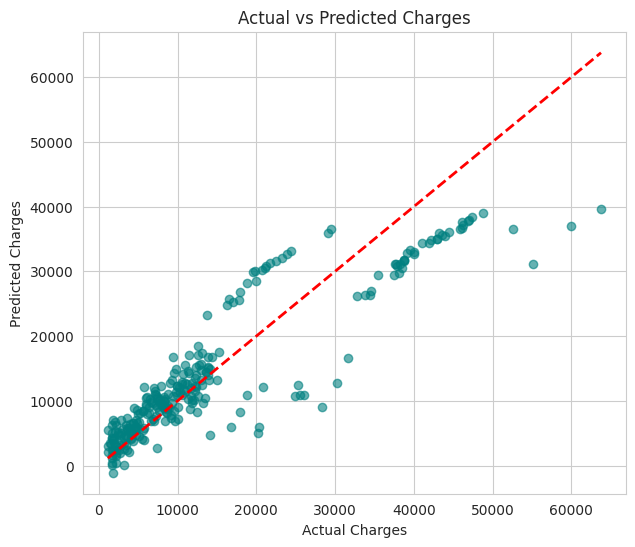

In [ ]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Actual vs Predicted Charges')
plt.show()


## Task 9: Result Interpretation


In [ ]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', key=abs, ascending=False)

coefficients


,Feature,Coefficient
4,smoker_yes,23077.764593
6,region_southeast,-838.919616
7,region_southwest,-659.139752
2,children,533.009989
5,region_northwest,-391.761455
1,bmi,318.701441
0,age,248.210720
3,sex_male,-101.542054


**Interpretation:**
- The model achieves an R² score of roughly **0.81**, meaning it explains about 78% of the variance in medical charges — a reasonably strong fit for a simple linear model.
- **`smoker_yes`** has by far the largest positive coefficient, confirming that smoking status is the single biggest driver of higher insurance charges (smokers pay thousands more on average, holding other factors constant).
- **`age`** and **`bmi`** both have positive coefficients, meaning charges increase steadily with age and with higher BMI.
- **`children`**, `sex`, and `region` have much smaller coefficients, indicating they have a comparatively minor influence on predicted charges.
- The MAE and RMSE values show the model's predictions are off by a few thousand dollars on average, which is reasonable given that a simple linear model cannot fully capture the sharp cost jump for high-BMI smokers seen in the EDA (a nonlinear/interaction effect).


## Task 10: Final Conclusion

**Summary of findings:**
- The dataset (1,338 records, no missing values) was cleanly loaded and explored with no major data quality issues.
- EDA revealed that **smoking status is the dominant factor** affecting insurance charges, followed by **age** and **BMI**. Charges are right-skewed, with smokers — especially those with high BMI — forming a distinct high-cost group.
- Categorical variables were encoded and the data split 80/20 for training and testing.
- A **Linear Regression** model was built and evaluated, achieving an **R² score of ~0.78**, showing it captures the major linear trends in the data well.

**Key insights from EDA and the model:**
1. Being a smoker is associated with dramatically higher medical charges than any other single factor.
2. Age and BMI both have a positive, roughly linear relationship with charges.
3. Number of children, sex, and region have minimal influence on predicted charges.
4. The linear model's main limitation is the nonlinear interaction between `smoker` and `bmi` (very high charges for smokers with high BMI), which a simple linear model can only partially capture — this points to potential future improvement using polynomial features or interaction terms, or a non-linear model such as Random Forest or Gradient Boosting.
